In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.stats import norm

[[[0 0 0]]

 [[1 1 1]]]


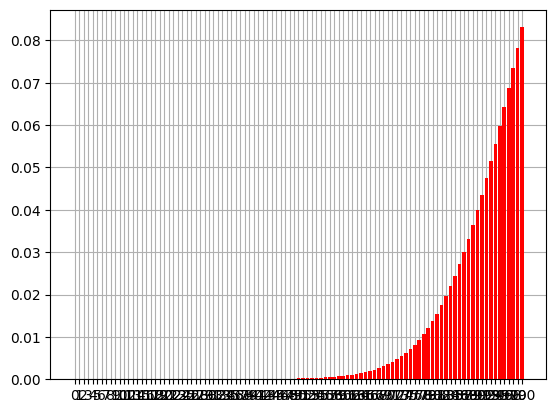

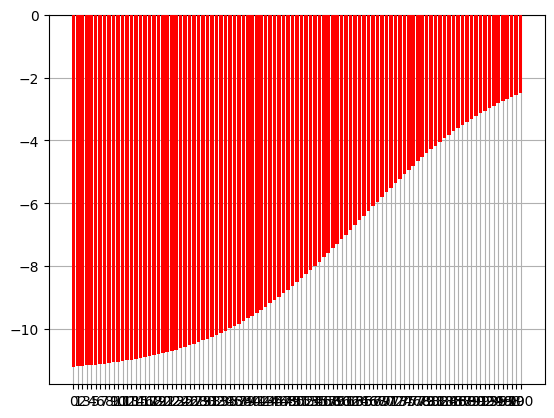

In [2]:
from pymdp import utils
import numpy as np
from scipy.stats import norm
import math
from pymdp.maths import softmax

import jax.numpy as jnp
import jax.tree_util as jtu
from jax import random as jr, config, jit
from pymdp.jax.agent import Agent as AIFAgent
from functools import partial
from equinox import tree_at

from pymdp.jax.maths import log_stable
import jax


seedjax=38
seed_value=3
num_slot=2
num_iter=32
tau=0.1
use_param_info_gain=False
learn_A=False
learn_B=False
e=0.001#
Timerange=4
initial_mean1=25
initial_mean2=60
initial_mean3=50
initial_mean4=50
initial_mean=[initial_mean1,initial_mean2,initial_mean3,initial_mean4]
sa1=0.001
sa2=0.001
sa3=8
sa4=12

sa=[sa1, sa2,sa3,sa4]

sb1=0.001
sb2=sb1
sb3=sb1#4.28
sb4=sb3#sb1
sb=[sb1, sb2,sb3,sb4]
sA1=sa1#0.16
sA2=sA1
sA3=sA1
sA4=sA1
sA=[sA1, sA2,sA3,sA4]
#objective_function=pbs+pbs_pA
deltaS1=0
deltaS2=0
deltaS3=0
deltaS4=0
deltaS=[deltaS1,deltaS2,deltaS3,deltaS4]
num_dim=100

cgrad=10#15#1#15#7.06#0.5#7.06#選好関数の傾き##10fig保存用
b=0.06
x_mid=65
alpha=1

num_obs=[]
num_states=[]
num_controls=[]
for i in range(num_slot):
    num_obs.append(num_dim+1)
    num_states.append(num_dim)
    num_controls.append(num_slot)
num_obs.append(num_slot)
num_states.append(num_slot)
num_controls.append(num_slot)

num_states_A = [num_dim,  num_slot]
Ns1=num_states[0]

policies = np.array([[[i] * (num_slot + 1)] for i in range(num_slot)])
print(policies)
num_factors = len(num_states)
D = utils.obj_array(num_factors)
for i in range(num_slot):
    D[i] = np.ones(num_dim)/num_dim

D[num_slot] = np.array([1/num_slot for _ in range(num_slot)])
D_env=utils.obj_array(num_factors)
for k in range(0,num_slot,1):
    D_env[k]=np.zeros(num_dim, dtype=float)
    D_env[k][initial_mean[k]-1] = 1.0

l = np.arange(0,num_dim,1)                 
A_shapes = [[o_dim] + num_states_A for o_dim in num_obs[0:num_slot]]# [4] + num_states_A2 
A_shapes.append([num_slot,num_slot])
A_array = utils.obj_array_zeros(A_shapes)

for j in range(num_slot):
    for m in range(0,num_states[j],1):
        for n in range(num_slot):
            if n==j:
                A_array[j][0,m,n]=0 
                A_array[j][1:(num_dim+1),m,n]=norm.pdf(l, m, sa[j])#+e

            else:
                A_array[j][0,m,n]=1
        
for q in range(0,num_states[num_slot],1):
    
    A_array[num_slot][q,q]=1

A_array = utils.norm_dist_obj_arr(A_array)            

B_shapes = [[s_dim, s_dim, num_controls[f]] for f, s_dim in enumerate(num_states)]

B_array = utils.obj_array_zeros(B_shapes)


for k in range(0,num_slot,1):
    for u in range(0,num_controls[k],1):
        for st in range(0,num_states[k],1): 
            B_array[k][:,st,u]=norm.pdf(l, st, sb[k])


for controls in range(0,num_states[num_slot],1):
    B_array[num_slot][controls,:,controls]=[1] * num_slot
B_array = utils.norm_dist_obj_arr(B_array)  

C_shapes = [[o_dim] for o_dim in num_obs]
C_vector = utils.obj_array_zeros(C_shapes)



eps = 1e-12
for k in range(0, num_slot, 1):
    for m in range(0, num_obs[k], 1):
        x = m
        t = b * (x - x_mid)
        sig = 1.0 / (1.0 + math.exp(-t))  # 0..1
        C_vector[k][m] = cgrad * sig #+ eps



from pymdp.utils import plot_beliefs, plot_likelihood,plot_likelihood_figsize
plot_beliefs(softmax(C_vector[0]))

for i in range(num_slot):
    C_vector[i]=np.log(softmax(C_vector[i]))

plot_beliefs(C_vector[0])

In [3]:
class FourArmedBandit(object):

  def __init__(self, D_env):
    rand_seq=[]
    rng = np.random.default_rng(seed=seed_value)
    self.s_slot=np.zeros((num_slot), dtype=int)
    for i in range (num_slot):
      np.random.seed(seed_value+i)  
      self.s_slot[i]=utils.sample(D_env[i])
      print(f"slot{i}:",self.s_slot[i])
      rand_seq.append(rng.normal(loc=0.0, scale=sb[i], size=2*Timerange))
    self.idx = np.zeros((num_slot), dtype=int)
    np.random.seed(seed_value)  

    self.rand_seq = rand_seq

  def step(self, action_idx):
    obs_slot=np.zeros((num_slot))
    obs_action=0 

    for i in range(num_slot):
      u1 = self.rand_seq[i][self.idx[i]]; self.idx[i] += 1

      nexts=round(self.s_slot[i]+deltaS[i]+u1)
      self.s_slot[i]=nexts
      
      if self.s_slot[i]>num_dim-1:
          self.s_slot[i]-=num_dim
      if self.s_slot[i]<0:
          self.s_slot[i]+=num_dim
    
    
    action_idx= action_idx[0][num_slot] 
      
    A_env=np.zeros((num_dim+1))
    A_env[0]=0
    A_env[1:num_dim+1]=norm.pdf(l,self.s_slot[action_idx],sA[action_idx])
    A_env = A_env/np.sum(A_env)
    obs_slot[action_idx] = utils.sample(A_env)
    obs_action=action_idx
    
    obs_slot=list(obs_slot)
    obs_slot.append(obs_action)

    obs_jax = jtu.tree_map(lambda x: jnp.expand_dims(x, -1).astype(jnp.int32), obs_slot)#jax用にbatch次元？を追加
    true_s =list(self.s_slot)
    return obs_jax,true_s
  
  def reset(self):
    obs_slot=np.zeros((num_slot))
    obs_action=0

    action_idx= self.s_action
      
    A_env=np.zeros((num_dim+1))
    A_env[0]=0
    A_env[1:num_dim+1]=norm.pdf(l,self.s_slot[action_idx],sA[action_idx])
    A_env = A_env/np.sum(A_env)
    obs_slot[action_idx] = utils.sample(A_env)
    obs_action=action_idx
    obs_slot=list(obs_slot)
    obs_slot.append(obs_action)

    obs_jax = jtu.tree_map(lambda x: jnp.expand_dims(x, -1).astype(jnp.int32), obs_slot)
    actions_t=[]
    for i in range(num_slot):
      actions_t.append(action_idx)
    actions_t=np.array([actions_t])

    return obs_jax, actions_t

In [4]:
from jax import nn
def calc_action_selection_prob(agent,neg_efe):
    neg_efe_tmp=neg_efe.flatten()
    q_pi=nn.softmax(agent.gamma * neg_efe_tmp)
    q_pi=jnp.expand_dims(q_pi, -2)
    return q_pi


In [5]:

batch_size = 1 

#jax

A_jax = jtu.tree_map(lambda x: jnp.broadcast_to(x, (batch_size,) + x.shape), list(A_array))#jax用にbatch次元を追加．
B_jax = jtu.tree_map(lambda x: jnp.broadcast_to(x, (batch_size,) + x.shape), list(B_array))
C_jax = jtu.tree_map(lambda x: jnp.broadcast_to(x, (batch_size,) + x.shape), list(C_vector))
D_jax = jtu.tree_map(lambda x: jnp.broadcast_to(x, (batch_size,) + x.shape), list(D))

batch_keys = jr.split(jr.PRNGKey(0), batch_size) 

A_dependencies = [[i, num_slot] for i in range(num_slot)] + [[num_slot]]

B_dependencies=None

agents = AIFAgent(A=A_jax, B=B_jax, C=C_jax, D=D_jax, E=None, pA=None, pB=None,  inference_algo="mmp", learn_A=learn_A, learn_B=learn_B, learn_C=False, learn_D=False, learn_E=False, A_dependencies=A_dependencies, B_dependencies=B_dependencies, policies=policies,gamma=1., alpha=alpha, action_selection="stochastic", policy_len=1, use_utility=True, use_states_info_gain=True, use_param_info_gain=use_param_info_gain, use_inductive=False, onehot_obs=False, sampling_mode="full",num_iter=num_iter)



In [6]:
@partial(jit, static_argnames=['batch_size','num_history'])
def update_agent_inference(agents, outcomes, actions, infer_args, batch_keys,expected_states, batch_size=1, num_history=1000):


    #beliefs,err, vfe,kld2, bs, un = agents.infer_states_vfe(outcomes, infer_args[0], past_actions=actions, qs_hist=infer_args[1])
    beliefs,err, vfe,kld2, bs, un, qs_1step, err_1step, vfe_1step, kld2_1step, bs_1step, un_1step = agents.infer_states_vfe_set_prior(outcomes, infer_args[0], past_actions=actions, qs_hist=infer_args[1],expected_states=expected_states, tau=tau)
    kld = agents.calc_KLD_past_currentqs(expected_states, infer_args[1], beliefs)
    outcomes = jtu.tree_map( lambda x: x[:, -num_history:], outcomes)

    beliefs_temp = jtu.tree_map( lambda x: x[:, -num_history:], beliefs)

    actionstmp = jtu.tree_map( lambda x: x[:,-num_history:], actions)
    beliefs_last = jtu.tree_map( lambda x: x[:, -1:], beliefs_temp) # take the last belief
    outcomes_last = jtu.tree_map( lambda x: x[:, -1:], outcomes) # take the last outcome
    applied_actions_last = jtu.tree_map( lambda x: x[:,-1:], actionstmp) # take the last applied action#applied_actions_last = jtu.tree_map( lambda x: x[:,-2:-1], actions) 
    beliefs_last_pair = jtu.tree_map( lambda x: x[:, -2:], beliefs_temp) # take the last two beliefs

    if applied_actions_last is None:
        q_pi, neg_efe, pbs, pkld, pfe, oRisk, pbs_pA, pbs_pB,I_B_o,I_B_o_se = agents.infer_policies_efe(beliefs)##
   
        batch_keys = jr.split(batch_keys[0], batch_size)#乱数のシャッフル
        actions_t = agents.sample_action(q_pi, rng_key=batch_keys)
        if actions is not None:
            actionstmp = jnp.concatenate([actionstmp, jnp.expand_dims(actions_t, -2)], -2)
        else:
            actionstmp = jnp.expand_dims(actions_t, -2)
        applied_actions_last = jtu.tree_map( lambda x: x[:,-2:-1], actionstmp)
    # Dの学習
    agents = tree_at(lambda x: x.D, agents, jtu.tree_map(lambda x: x[:, 0], beliefs_temp)) 


    vfe =jnp.array(vfe)
    vfe_1step =jnp.array(vfe_1step)
    bs =jnp.array(bs)
    bs_1step =jnp.array(bs_1step)
    un =jnp.array(un)
    un_1step =jnp.array(un_1step)

    return agents, outcomes, actions, infer_args, batch_keys,  vfe,  bs, un, kld, beliefs, vfe_1step


In [7]:

@partial(jit, static_argnames=['batch_size','num_history'])
def update_agent_action_sampling(agents, outcomes, actions, infer_args, batch_keys, beliefs, batch_size=1, num_history=1000):

    q_pi, neg_efe, pbs,pbs_st, pkld, pfe, oRisk, pbs_pA, pbs_pB,_,I_B_o,Hqs = agents.infer_policies_efe_curiosity(beliefs)##

    Hqo=pfe-pkld
    negefe_tmp=neg_efe[0]-pbs_pA[0]-pbs_pB[0]
    Pv=-oRisk-Hqo
    ambi=pfe-pbs-pkld
    Hqs=jnp.array([Hqs[0,0,0],Hqs[0,0,1]])

    batch_keys = jr.split(batch_keys[0], batch_size)

    q_pi=calc_action_selection_prob(agents,pbs+Pv)

    
    actions_t = agents.sample_action(q_pi, rng_key=batch_keys)

    if actions is not None:
        actions = jnp.concatenate([actions, jnp.expand_dims(actions_t, -2)], -2)
    else:
        actions = jnp.expand_dims(actions_t, -2)
    outcomes = jtu.tree_map( lambda x: x[:, -num_history:], outcomes)

    beliefs = jtu.tree_map( lambda x: x[:, -num_history:], beliefs)

    actions = jtu.tree_map( lambda x: x[:,-num_history:], actions)

    infer_args = agents.update_empirical_prior(actions_t, beliefs)

    return agents, outcomes, actions, infer_args, batch_keys, neg_efe, pbs, pbs_pA, pbs_pB,  Hqo, pkld, pfe, oRisk,q_pi,I_B_o,Hqs,pbs_st

In [8]:
T=Timerange


key = jr.PRNGKey(seedjax)
batch_keys = jr.split(key, T)

slot_counts = [0 for _ in range(num_slot)]
array_selected_slot=[]
EFE=[]
prior_VFE=[]
posterior_VFE=[]
VFE=[]
PBS=[]
PKLD=[]
PFE=[]
Risk=[]
Ambiguity=[]
Pragmaticvalue=[]
KLD=[]
BS=[]
pBS_pA=[]
pBS_pB=[]
H_qo=[]
Q_pi=[]
PBS_st=[]
H_qs=[]

prediction_performance=[]


my_env=FourArmedBandit(D_env)

prior_beliefs=jtu.tree_map(lambda x: jnp.expand_dims(x, -2), agents.D)
q_pi, neg_efe, pbs,pbs_st, pkld, pfe, oRisk, pbs_pA, pbs_pB,_,I_B_o,Hqs = agents.infer_policies_efe_curiosity(prior_beliefs)


Hqo=pfe-pkld
Pv=-oRisk-Hqo
Hqs=jnp.array([Hqs[0,0,0],Hqs[0,0,1]])

q_pi=calc_action_selection_prob(agents,Pv+pbs)
batch_keys = jr.split(batch_keys[0], batch_size)
actions_t = agents.sample_action(q_pi, rng_key=batch_keys)
first_action=actions_t
obs,true_s  = my_env.step(actions_t)

obs_record=[obs]

last_action=first_action[0][num_slot]
D[num_slot][first_action[0][num_slot]] = 1
D_jax = jtu.tree_map(lambda x: jnp.broadcast_to(x, (batch_size,) + x.shape), list(D))
agents = tree_at(lambda x: x.D, agents, D_jax) 

PBS.append(pbs)
PKLD.append(pkld)
PFE.append(pfe)
Risk.append(oRisk)  
ambi=pfe-pbs-pkld
Ambiguity.append(ambi)
Pragmaticvalue.append(Pv)
H_qo.append(Hqo)
H_qs.append(Hqs)
EFE.append(-1*neg_efe)
pBS_pA.append(pbs_pA) 
pBS_pB.append(I_B_o)#pbs_pB2

PBS_st.append(pbs_st)
Q_pi.append(q_pi)
selected_slot = int(actions_t[0][num_slot]) 
slot_counts[selected_slot] += 1
array_selected_slot.append(first_action[0][num_slot]+1)

beliefs=None

for t in range(T):
  if t == 0:
      
      actions_t = None 
      actions = None 
      prob_pi = None
      infer_args = (agents.D, None,)
      outcome_t  = None
      outcomes = None
      
      expected_state =agents.D 
  else:
      print("selected action",actions_t)
      expected_state = agents.compute_expected_state(actions_t, infer_args[1])

  q_trues=jtu.tree_map(lambda x,i: x[0][i], expected_state[:num_slot],true_s)
  ln_q_trues=jtu.tree_map(lambda x: -1*log_stable(x), q_trues)
  prediction_performance.append(ln_q_trues)


  batch_keys = jr.split(batch_keys[0], batch_size)
  outcome_t  = jtu.tree_map(lambda x: jnp.expand_dims(x, -1), obs)
  num_history=10 
  if outcomes is None:
      outcomes = outcome_t
  else:
      
      outcomes = jtu.tree_map(lambda prev_o, new_o: jnp.concatenate([prev_o, new_o], -1), outcomes, outcome_t) 
  pB_old=agents.pB
  B_old=agents.B
  
  agents, outcomes, actions, infer_args, batch_keys,  posterior_vfe,  bs, un, kld, beliefs,prior_vfe = update_agent_inference(
      agents, 
      outcomes, 
      actions, 
      infer_args, 
      batch_keys,
      expected_state,
      batch_size=batch_size,
      num_history=num_history
  )
  prior_vfe=prior_vfe[0:num_slot].sum(axis=0)
  prior_vfe=prior_vfe[:,-1]
  prior_VFE.append(prior_vfe)

  posterior_vfe=posterior_vfe[0:num_slot].sum(axis=0)
  posterior_vfe=posterior_vfe[:,-1]
  posterior_VFE.append(posterior_vfe)

  bs=bs[0:num_slot].sum(axis=0)#bs.sum(0)
  bs=bs[:,-1]
  kld=jnp.array(kld)
  kld=kld[0:num_slot].sum(axis=0)
  kld=kld[:,-1]

  if actions is not None:
    last_action_tmp = jtu.tree_map( lambda x: x[:,-1:], actions)
    last_action=last_action_tmp[-1][-1][-1]

  agents, outcomes, actions, infer_args, batch_keys, neg_efe, pbs,  pbs_pA, pbs_pB,  Hqo, pkld, pfe, oRisk, q_pi,I_B_o,Hqs,pbs_st = update_agent_action_sampling(
      agents, 
      outcomes, 
      actions, 
      infer_args, 
      batch_keys,
      beliefs,
      batch_size=batch_size,
      num_history=num_history
  )
  print(f"oRisk",oRisk[-1])
  print(f"q_pi",q_pi)
  print(f"I_B_o:",I_B_o)
  print(f"Hqs:",Hqs)
 
  actions_t = actions[:,-1]
  obs ,true_s = my_env.step(actions_t)
  obs_record.append(obs)
 
  BS.append(bs)
  KLD.append(kld)
  
  selected_slot = int(actions_t[0][num_slot]) 
  
  if t<T-1:
    array_selected_slot.append(actions_t[0][num_slot]+1)
    slot_counts[selected_slot] += 1
    PBS.append(pbs) 
    PKLD.append(pkld)
    PFE.append(pfe)
    Risk.append(oRisk)  
    ambi=pfe-pbs-pkld
    Ambiguity.append(ambi)
    Pv=-oRisk-Hqo
    Pragmaticvalue.append(Pv)
    pBS_pA.append(pbs_pA)
    pBS_pB.append(I_B_o)

    EFE.append(-1*neg_efe)
    PBS_st.append(pbs_st)
    H_qo.append(Hqo)
    H_qs.append(Hqs)
    Q_pi.append(q_pi)



PBS=jtu.tree_map(lambda x: jnp.reshape(x, (num_slot,)), PBS) 
PBS=np.array(PBS) 
PBS=PBS.T
PBS=PBS.tolist()
PKLD=jtu.tree_map(lambda x: jnp.reshape(x, (num_slot,)), PKLD) 
PKLD=np.array(PKLD) 
PKLD=PKLD.T
PKLD=PKLD.tolist()
PFE=jtu.tree_map(lambda x: jnp.reshape(x, (num_slot,)), PFE) 
PFE=np.array(PFE) 
PFE=PFE.T
PFE=PFE.tolist()
Ambiguity=jtu.tree_map(lambda x: jnp.reshape(x, (num_slot,)), Ambiguity) 
Ambiguity=np.array(Ambiguity) 
Ambiguity=Ambiguity.T
Ambiguity=Ambiguity.tolist()
Risk=jtu.tree_map(lambda x: jnp.reshape(x, (num_slot,)), Risk) 
Risk=np.array(Risk) 
Risk=Risk.T
Risk=Risk.tolist()
Pragmaticvalue=jtu.tree_map(lambda x: jnp.reshape(x, (num_slot,)), Pragmaticvalue) 
Pragmaticvalue=np.array(Pragmaticvalue) 
Pragmaticvalue=Pragmaticvalue.T
Pragmaticvalue=Pragmaticvalue.tolist()

EFE=jtu.tree_map(lambda x: jnp.reshape(x, (num_slot,)), EFE) 
EFE=np.array(EFE)
EFE=EFE.T
EFE=EFE.tolist()

pBS_pA=jtu.tree_map(lambda x: jnp.reshape(x, (num_slot,)), pBS_pA) 
pBS_pA=np.array(pBS_pA) 
pBS_pA=pBS_pA.T
pBS_pA=pBS_pA.tolist()

pBS_pB=jtu.tree_map(lambda x: jnp.reshape(x, (num_slot,)), pBS_pB) 
pBS_pB=np.array(pBS_pB) 
pBS_pB=pBS_pB.T
pBS_pB=pBS_pB.tolist()

H_qo=jtu.tree_map(lambda x: jnp.reshape(x, (num_slot,)), H_qo) 
H_qo=np.array(H_qo) 
H_qo=H_qo.T
H_qo=H_qo.tolist()

H_qs=jtu.tree_map(lambda x: jnp.reshape(x, (num_slot,)), H_qs) 
H_qs=np.array(H_qs) 
H_qs=H_qs.T
H_qs=H_qs.tolist()

PBS_st=jtu.tree_map(lambda x: jnp.reshape(x, (num_slot,)), PBS_st) 
PBS_st=np.array(PBS_st) 
PBS_st=PBS_st.T
PBS_st=PBS_st.tolist()


selected_slot_array=[x.tolist() for x in array_selected_slot]

slot0: 24
slot1: 59
oRisk [14.287924 18.341976]
q_pi [[0.98294413 0.01705596]]
I_B_o: [[0. 0.]]
Hqs: [4.6051698e+00 2.7579297e-12]
selected action [[0 0 0]]
oRisk [21.763218 18.33937 ]
q_pi [[0.03155844 0.96844155]]
I_B_o: [[0. 0.]]
Hqs: [1.5701149e-13 8.3095976e-13]
selected action [[1 1 1]]
oRisk [21.763218 18.33937 ]
q_pi [[0.03155844 0.96844155]]
I_B_o: [[0. 0.]]
Hqs: [7.9232611e-13 2.1559225e-14]
selected action [[1 1 1]]
oRisk [21.763218 18.33937 ]
q_pi [[0.03155844 0.96844155]]
I_B_o: [[0. 0.]]
Hqs: [7.923261e-13 2.155495e-14]


In [9]:
import numpy as np


def calculate_pbs_absdiff(PBS):

    abs_diffs = []

    for t in range(len(PBS[0])):  
        diff_t = abs(PBS[0][t] - PBS[1][t])  
        abs_diffs.append(diff_t)

    return abs_diffs


pbs_st_absdiff = calculate_pbs_absdiff(PBS_st)
pbs_absdiff = calculate_pbs_absdiff(PBS)
I_B_o_absdiff = calculate_pbs_absdiff(pBS_pB)
H_qo_absdiff = calculate_pbs_absdiff(H_qo)
H_qs_absdiff = calculate_pbs_absdiff(H_qs)
total_absdiff = calculate_pbs_absdiff(list(np.array(PBS_st)+np.array(PBS)))





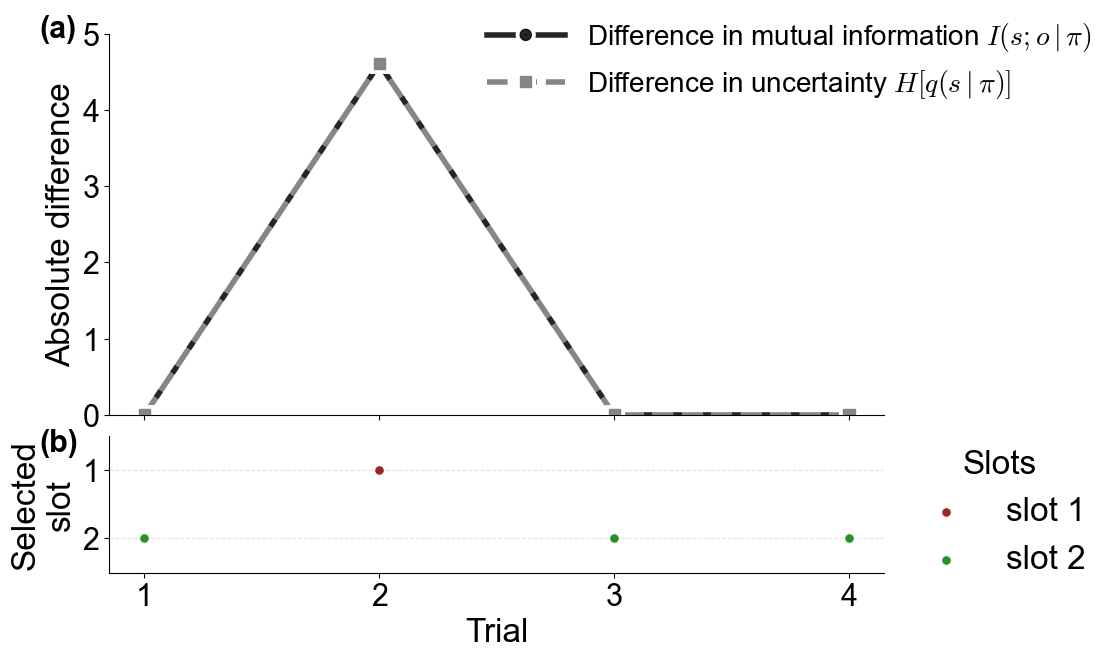

(np.float64(0.3333333333333333), np.int64(1))


In [10]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
linewidth=4
markersize=8
font = "Arial"#"Times New Roman"
T = len(pbs_absdiff)
x = np.arange(1, T + 1)

iso = np.asarray(pbs_absdiff)
hqs = np.asarray(H_qs_absdiff)
actions = np.asarray(selected_slot_array)

assert len(hqs) == T
assert len(actions) == T

plt.rcParams.update({
     "text.usetex": False,#True,
    # "font.family": "serif",
    # "font.serif": ["Times New Roman"],
    "font.family": "sans-serif",
    "font.sans-serif": [font,"Helvetica", "DejaVu Sans"],
    "mathtext.fontset": "cm", 
    # "mathtext.fontset": "custom",
    # "mathtext.rm": "Helvetica",
    # "mathtext.it": "Helvetica:italic",
    # "mathtext.bf": "Helvetica:bold",
    "xtick.labelsize": 22,#18,
    "ytick.labelsize": 22,#18,
    "axes.labelsize": 24,#20,
    "legend.fontsize": 20,#24,#16,
})

fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(10, 7),
    sharex=True,
    gridspec_kw={
        "height_ratios": [3.2, 1.15],
        "hspace": 0.08
    }
)


outline = [
    pe.Stroke(linewidth=linewidth + 2.5, foreground="white"),
    pe.Normal()
]

ax1.plot(
    x, iso,
    marker="o",
    linewidth=linewidth,
    markersize=markersize,
    linestyle="-",
    color="black",
    alpha=0.85,
    label=r"Difference in mutual information $I(s; o \mid \pi)$",
    path_effects=outline,
    zorder=3
)

ax1.plot(
    x, hqs,
    marker="s",
    linewidth=linewidth,
    markersize=markersize,
    linestyle="--",
    color="gray",
    alpha=0.95,
    label=r"Difference in uncertainty $H[q(s \mid \pi)]$",
    path_effects=outline,
    zorder=4
)

ax1.set_ylabel("Absolute difference", fontname=font)
ax1.set_ylim(bottom=0, top=5)

ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)

ax1.legend(
    frameon=False,
    loc="upper right",
    bbox_to_anchor=(1.3, 1.1),
    handlelength=2.8
)


ax1.tick_params(axis="x", labelbottom=False)


colors = ["darkred", "green", "orange", "purple"]
slot_labels = [f"slot {i+1}" for i in range(num_slot)]

for slot in range(1, num_slot + 1):
    slot_trials = x[actions == slot]
    ax2.scatter(
        slot_trials,
        np.full_like(slot_trials, slot),
        color=colors[slot - 1],
        label=slot_labels[slot - 1],
        s=45,
        alpha=0.85,
        edgecolor="white",
        linewidth=0.6,
        zorder=3
    )

ax2.set_xlabel("Trial", fontname=font)
ax2.set_ylabel("Selected\nslot", fontname=font)

ax2.set_yticks(np.arange(1, num_slot + 1))
ax2.set_ylim(num_slot + 0.5, 0.5)  # invert y-axis

ax2.grid(axis="y", linestyle="--", alpha=0.35)

ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)

ax2.legend(
    title="Slots",
    frameon=False,
    fontsize=24,#14,
    title_fontsize=24,#15,
    bbox_to_anchor=(1.02, 1.0),
    loc="upper left",
    borderaxespad=0.
)
# -------------------------
# Panel labels (a), (b)
# -------------------------

ax1.text(
    -0.09, 1.05, "(a)",
    transform=ax1.transAxes,
    fontsize=22,#20,
    fontweight="bold",
    va="top",
    ha="left"
)

ax2.text(
    -0.09, 1.05, "(b)",
    transform=ax2.transAxes,
    fontsize=22,#20,
    fontweight="bold",
    va="top",
    ha="left"
)

# x-axis ticks
ax2.set_xticks(np.arange(1, T + 1))

# -------------------------
# Save
# -------------------------

filename = f"Combined_diff_slot_sa2{sa2}_sb{sb1}.tif"

fig.savefig(
    filename,
    format="tiff",
    dpi=1200,
    bbox_inches="tight"
)

plt.show()


def consecutive_ratio(selected_slot_array):
    arr = np.asarray(selected_slot_array)
    consecutive = arr[:-1] == arr[1:]
    ratio = consecutive.sum() / len(consecutive)
    return ratio, consecutive.sum()

print(consecutive_ratio(actions))